# Tiempo de extinción del proceso de contacto con pesos sobre el grafo completo

Este notebook reúne y organiza las simulaciones de **tiempo de extinción frente al tamaño del grafo** utilizadas en el trabajo de grado. Se conserva únicamente el material necesario para estudiar los tres regímenes del proceso:

$$
\lambda<\lambda_c \quad \text{(subcrítico)},\qquad
\lambda=\lambda_c \quad \text{(crítico)},\qquad
\lambda>\lambda_c \quad \text{(supercrítico)}.
$$

Todas las simulaciones utilizan una **única implementación** del método directo de Gillespie. Para acelerar el Paso 3b del pseudocódigo —la elección de un vértice sano que se infectará con probabilidad proporcional a su peso— se utiliza un **Fenwick tree**. Esta optimización no cambia las tasas ni la ley del proceso; solamente reduce el costo computacional de la selección ponderada. Además, las funciones numéricas que se ejecutan repetidamente se compilan mediante `numba` para reducir el costo de los bucles del algoritmo.

Las simulaciones se calculan una sola vez y luego se reutilizan en las figuras. En particular, los tres regímenes se estudian hasta $n=500$, y para cada uno se presentan paneles con $n\le 200$ y $n\le 500$.

Las figuras finales son:

1. tiempo de extinción en el régimen subcrítico;
2. tiempo de extinción en el régimen crítico;
3. tiempo de extinción en el régimen supercrítico;
4. comparación del comportamiento crítico con la curva logarítmica subcrítica y curva exponencial supercrítica.


## 1. Modelo, notación y tiempo de extinción

Sea

$$
G=(V,E),\qquad V=\{1,\ldots,n\},
$$

el grafo completo. Condicionamos en una realización de la sucesión de pesos

$$
\mathbf w=(w_i)_{i \ge 0}.
$$

El proceso inicia con todos los vértices infectados,

$$
\eta_0^V=V,
$$

y en el tiempo $t$ escribimos

$$
I_t=\{i\in V:\eta_t^V(i)=1\},
\qquad
S_t=\{i\in V:\eta_t^V(i)=0\}.
$$

Definimos además

$$
W_{I_t}=\sum_{i\in I_t}w_i,
\qquad
W_{S_t}=\sum_{j\in S_t}w_j.
$$

Las tasas agregadas del método directo de Gillespie son

$$
\lambda_{\mathrm{rec}}=|I_t|,
\qquad
\lambda_{\mathrm{inf}}=
\frac{\lambda}{n}W_{I_t}W_{S_t},
$$
y
$$
\Lambda=\lambda_{\mathrm{rec}}+\lambda_{\mathrm{inf}}.
$$

El **tiempo de extinción** se define por

$$
\tau_{\mathrm{ext}}
=
\inf\{t\ge 0:I_t=\varnothing\}
=
\inf\{t\ge0:|I_t|=0\}.
$$

En todas las simulaciones se consideran pesos

$$
w_1\sim\Gamma(k=2,\theta=1).
$$
Como
$$
\mathbb E(w_1^2)=k(k+1)\theta^2=6,
$$
el valor crítico es
$$
\lambda_c=\frac{1}{\mathbb E(w_1^2)}=\frac16\approx0.1667.
$$

Se utilizan

$$
\lambda_{\mathrm{sub}}=0.10,
\qquad
\lambda_{\mathrm{cri}}=\lambda_c,
\qquad
\lambda_{\mathrm{sup}}=0.25.
$$

## 2. Correspondencia con el pseudocódigo y uso del Fenwick tree

La simulación sigue los mismos pasos del pseudocódigo presentado en la Sección 5.4:

| Paso | Operación |
|---|---|
| 0a | Inicializar $t$, $I_t$, $S_t$, $W_{I_t}$ y $W_{S_t}$ |
| 0b | Calcular $\lambda_{\mathrm{rec}}$, $\lambda_{\mathrm{inf}}$ y $\Lambda$ |
| 1 | Generar $U_1\sim\mathrm{Unif}(0,1)$ y $\tau=-\log(U_1)/\Lambda$ |
| 2 | Generar $U_2\sim\mathrm{Unif}(0,\Lambda)$ y determinar el tipo de evento |
| 3a | Si ocurre recuperación, elegir $i\in I_t$ uniformemente |
| 3b | Si ocurre infección, elegir $j\in S_t$ con probabilidad $w_j/W_{S_t}$ |
| 4 | Actualizar $t\leftarrow t+\tau$ |
| 5 | Actualizar incrementalmente $W_{I_t}$ y $W_{S_t}$ |
| 6 | Repetir hasta que $|I_t|=0$ |



### Fenwick tree

Implementaremos Fenwick tree únicamente en el **Paso 3b**. Definimos

$$
x_j(t)=w_j\mathbf 1_{\{j\in S_t\}}
$$

y el Fenwick tree mantiene las sumas acumuladas

$$
F_t(k)=\sum_{j=1}^{k}x_j(t).
$$

Como $F_t(n)=W_{S_t}$, generamos

$$
U\sim\mathrm{Unif}(0,W_{S_t})
$$

y elegimos el menor índice $j$ tal que

$$
F_t(j)>U.
$$

El intervalo correspondiente a $j$ tiene longitud exactamente $w_j$, luego

$$
\mathbb P(j \in S_t \text{ se infecte }| \text{ ocurre una infección})
=
\frac{w_j}{W_{S_t}},
$$

que es **exactamente la misma distribución del pseudocódigo**.

La diferencia es exclusivamente computacional:

$$
O(|S_t|)\quad\longrightarrow\quad O(\log n)
$$

para la selección ponderada. Además, las actualizaciones del árbol después de una recuperación o infección también cuestan $O(\log n)$.

Para estas simulaciones de extinción se combina Fenwick tree con compilación JIT mediante `numba`, lo cual es especialmente útil en el régimen supercrítico, donde pueden ocurrir muchos eventos antes de la extinción.

In [ ]:
import math
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

try:
    from numba import njit
except ImportError:
    def njit(*args, **kwargs):
        if args and callable(args[0]):
            return args[0]
        return lambda f: f

# ============================================================
# Configuración general
# ============================================================
SEMILLA = 2026
MAX_EVENTOS_EXT = 100_000_000

GAMMA_K = 2.0
GAMMA_THETA = 1.0
EW2 = GAMMA_K * (GAMMA_K + 1.0) * GAMMA_THETA**2

LAMBDA_C = 1.0 / EW2
LAMBDA_SUB = 0.10
LAMBDA_CRI = LAMBDA_C
LAMBDA_SUP = 0.25

# Número de repeticiones Monte Carlo.
REPS_SUB = 50
REPS_CRI = 50
REPS_SUP = 20

# Cada régimen se simula una sola vez hasta n=500. Después se reutilizan
# subconjuntos para construir los paneles n<=200 y n<=500.
# Los pasos reducen el tiempo de cómputo sin cambiar el algoritmo.
PASO_N_SUB = 2
PASO_N_CRI = 2
PASO_N_SUP = 5

N_SUB = np.arange(5, 501, PASO_N_SUB)
N_CRI = np.arange(5, 501, PASO_N_CRI)
N_SUP = np.arange(10, 501, PASO_N_SUP)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
    "lines.linewidth": 2.2,
})

print(f"E[W²] = {EW2:.4f}")
print(f"lambda_c = {LAMBDA_C:.6f}")


E[W²] = 6.0000
lambda_c = 0.166667


## 3. Fenwick tree: operaciones básicas

El árbol se representa mediante un vector `tree`. No se construye una estructura diferente en cada simulación: las dos operaciones esenciales se definen una sola vez y se reutilizan siempre.

In [ ]:
@njit
def fenwick_update(tree, index, delta):
    """Añade delta al peso almacenado en el índice dado."""
    i = index + 1
    n = tree.size - 1

    while i <= n:
        tree[i] += delta
        i += i & -i


@njit
def fenwick_sample(tree, n, target):
    """
    Devuelve el menor índice j cuya suma acumulada es > target.
    Se requiere 0 <= target < suma total almacenada.
    """
    idx = 0
    bit = 1

    while (bit << 1) <= n:
        bit <<= 1

    while bit > 0:
        siguiente = idx + bit

        if siguiente <= n and tree[siguiente] <= target:
            target -= tree[siguiente]
            idx = siguiente

        bit >>= 1

    if idx >= n:
        return n - 1

    return idx

## 4. Implementación única del tiempo de extinción

La función siguiente es la única implementación del proceso utilizada en todo el notebook. A diferencia de una simulación de trayectoria completa, aquí no es necesario almacenar $(t,|I_t|)$ después de cada evento: para estudiar $\tau_{\mathrm{ext}}$ basta con evolucionar el proceso hasta $|I_t|=0$ y devolver el tiempo final. Esto reduce memoria y tiempo de ejecución sin modificar el proceso.

El código mantiene explícitamente las cantidades del pseudocódigo

$$
\lambda_{\mathrm{rec}},\quad
\lambda_{\mathrm{inf}},\quad
\Lambda,\quad
U_1,\quad U_2,\quad \tau.
$$

In [ ]:
@njit
def tiempo_extincion_gillespie_fenwick(
    w,
    lambda_,
    seed,
    max_eventos=MAX_EVENTOS_EXT,
):
    """
    Tiempo de extinción del proceso de contacto con pesos sobre G(E,V).

    Estado inicial: eta_0^V = V.
    Implementa el método directo de Gillespie y usa Fenwick tree
    únicamente para el Paso 3b.

    Retorna
    -------
    tau_ext : float
        Tiempo hasta |I_t|=0.
    eventos : int
        Número de eventos ejecutados.
    completo : bool
        True si se alcanzó la extinción antes de max_eventos.
    """
    np.random.seed(seed)

    n = w.size

    # --------------------------------------------------------
    # PASO 0a. Inicialización
    # --------------------------------------------------------
    t = 0.0

    # infected[0:I] contiene exactamente los vértices de I_t.
    infected = np.arange(n, dtype=np.int64)
    posicion = np.arange(n, dtype=np.int64)
    I = n

    # El Fenwick tree almacena w_j si j pertenece a S_t y 0 si j está infectado.
    tree_S = np.zeros(n + 1, dtype=np.float64)

    W_It = np.sum(w)
    W_St = 0.0

    eventos = 0

    # --------------------------------------------------------
    # PASO 6. Repetir hasta la extinción
    # --------------------------------------------------------
    while I > 0 and eventos < max_eventos:

        # ----------------------------------------------------
        # PASO 0b. Tasas agregadas
        # ----------------------------------------------------
        lambda_rec = float(I)
        lambda_inf = (lambda_ / n) * W_It * W_St
        Lambda = lambda_rec + lambda_inf

        if Lambda <= 0.0:
            return t, eventos, False

        # ----------------------------------------------------
        # PASO 1. Tiempo hasta el siguiente evento
        # ----------------------------------------------------
        U1 = np.random.random()
        if U1 < 1e-300:
            U1 = 1e-300

        tau = -math.log(U1) / Lambda

        # ----------------------------------------------------
        # PASO 2. Tipo de evento
        # ----------------------------------------------------
        U2 = np.random.random() * Lambda

        if U2 <= lambda_rec:
            # ------------------------------------------------
            # PASO 3a. Recuperación: i en I_t uniformemente
            # ------------------------------------------------
            k = np.random.randint(I)
            i = infected[k]

            ultimo = infected[I - 1]
            infected[k] = ultimo
            posicion[ultimo] = k
            posicion[i] = -1
            I -= 1

            wi = w[i]

            # ------------------------------------------------
            # PASO 5. Actualización incremental
            # ------------------------------------------------
            W_It -= wi
            W_St += wi
            fenwick_update(tree_S, i, wi)

        else:
            # ------------------------------------------------
            # PASO 3b. Infección: P(j)=w_j/W_St
            # ------------------------------------------------
            if W_St <= 0.0:
                continue

            U_ponderado = np.random.random() * W_St
            j = fenwick_sample(tree_S, n, U_ponderado)
            wj = w[j]

            # j debe ser un vértice sano que se infectará con peso positivo.
            if wj <= 0.0 or posicion[j] != -1:
                continue

            fenwick_update(tree_S, j, -wj)

            posicion[j] = I
            infected[I] = j
            I += 1

            # ------------------------------------------------
            # PASO 5. Actualización incremental
            # ------------------------------------------------
            W_St -= wj
            W_It += wj

        # ----------------------------------------------------
        # PASO 4. Avanzar el tiempo
        # ----------------------------------------------------
        t += tau
        eventos += 1

    return t, eventos, I == 0

## 5. Repeticiones Monte Carlo y resumen por tamaño del grafo

Para cada $n$, se realizan $R$ repeticiones independientes. En cada repetición se genera una nueva realización i.i.d. de

$$
\mathbf w=(w_i)_{i \ge 0},\qquad w_i\sim\Gamma(2,1),
$$

y posteriormente se simula el proceso hasta su extinción.

Para cada tamaño se almacenan:

- la media empírica de $\tau_{n}$;
- la desviación estándar empírica;
- el número medio de eventos de Gillespie.

En las figuras, la banda sombreada corresponde a

$$
\text{media}\pm 1\text{ desviación estándar},
$$

truncando el extremo inferior en cero.

> **Nota sobre el corte computacional.** Si una trayectoria alcanza `MAX_EVENTOS_EXT` antes de extinguirse, se registra como censurada. En los tamaños para los cuales existen trayectorias censuradas, la media calculada por el notebook corresponde únicamente a las trayectorias que alcanzaron la extinción antes del corte computacional; por tanto, no debe interpretarse como una estimación no censurada de $\mathbb E(\tau_n)$. El vector `censurados` permite identificar estos casos.


In [ ]:
def estimar_extincion_vs_n(
    n_values,
    lambda_,
    repeticiones,
    seed_base,
    k=GAMMA_K,
    theta=GAMMA_THETA,
    max_eventos=MAX_EVENTOS_EXT,
    mostrar_progreso=True,
):
    """Estima E[\tau_n] por Monte Carlo para cada n de n_values."""

    n_values = np.asarray(n_values, dtype=int)
    medias = np.empty(n_values.size, dtype=float)
    desviaciones = np.empty(n_values.size, dtype=float)
    eventos_medios = np.empty(n_values.size, dtype=float)
    censurados = np.zeros(n_values.size, dtype=int)

    inicio = time.perf_counter()

    for idx, n in enumerate(n_values):
        tiempos = np.empty(repeticiones, dtype=float)
        eventos = np.empty(repeticiones, dtype=float)

        for r in range(repeticiones):
            # Semillas separadas para el entorno de pesos y para Gillespie.
            semilla_w = seed_base + 1_000_003 * idx + 101 * r
            semilla_proc = seed_base + 2_000_033 * idx + 211 * r + 17

            rng_w = np.random.default_rng(semilla_w)
            w = rng_w.gamma(shape=k, scale=theta, size=n).astype(np.float64)

            T_ext, n_eventos, completo = tiempo_extincion_gillespie_fenwick(
                w=w,
                lambda_=lambda_,
                seed=semilla_proc,
                max_eventos=max_eventos,
            )

            if not completo:
                tiempos[r] = np.nan
                censurados[idx] += 1
            else:
                tiempos[r] = T_ext

            eventos[r] = n_eventos

        if censurados[idx] > 0:
            warnings.warn(
                f"n={n}: {censurados[idx]} trayectorias alcanzaron MAX_EVENTOS. "
            )

        validos = tiempos[np.isfinite(tiempos)]

        if validos.size == 0:
            medias[idx] = np.nan
            desviaciones[idx] = np.nan
        else:
            medias[idx] = np.mean(validos)
            desviaciones[idx] = np.std(validos, ddof=1) if validos.size > 1 else 0.0

        eventos_medios[idx] = np.mean(eventos)

        if mostrar_progreso:
            salto = max(1, n_values.size // 10)
            if idx == 0 or (idx + 1) % salto == 0 or idx == n_values.size - 1:
                print(
                    f"lambda={lambda_:.6f}: "
                    f"{idx + 1:>4}/{n_values.size} tamaños completados "
                    f"(n={n})"
                )

    duracion = time.perf_counter() - inicio

    print(
        f"Finalizado lambda={lambda_:.6f}: "
        f"{n_values.size} tamaños, R={repeticiones}, "
        f"tiempo total={duracion/60:.2f} min"
    )

    return {
        "n": n_values,
        "media": medias,
        "sd": desviaciones,
        "eventos_medios": eventos_medios,
        "censurados": censurados,
        "R": repeticiones,
        "lambda": lambda_,
    }


def recortar_resultados(resultados, n_max):
    mask = resultados["n"] <= n_max

    salida = {
        clave: (valor[mask] if isinstance(valor, np.ndarray) and valor.shape == resultados["n"].shape else valor)
        for clave, valor in resultados.items()
    }

    return salida

## 6. Ajustes de los órdenes teóricos

Las curvas se ajustan sobre los promedios Monte Carlo, sin volver a simular el proceso.

### Régimen subcrítico

Se ajusta $C\log n$. La línea roja de las figuras corresponde al ajuste obtenido directamente a partir de los promedios simulados.

### Régimen crítico

Se ajusta $n^{\alpha}$.

### Régimen supercrítico

Se ajusta $e^{cn}$.

Estos ajustes son **descriptivos de las simulaciones**.


In [ ]:
def datos_validos(resultados):
    n = np.asarray(resultados["n"], dtype=float)
    y = np.asarray(resultados["media"], dtype=float)
    mask = np.isfinite(n) & np.isfinite(y) & (n > 1) & (y > 0)
    return n[mask], y[mask]


def ajuste_logaritmico(resultados):
    n, y = datos_validos(resultados)
    x = np.log(n)
    c = np.dot(x, y) / np.dot(x, x)
    pred = c * x
    return c, n, pred


def ajuste_polinomial(resultados):
    n, y = datos_validos(resultados)
    alpha, log_A = np.polyfit(np.log(n), np.log(y), deg=1)
    A = np.exp(log_A)
    pred = A * n**alpha
    return A, alpha, n, pred


def ajuste_exponencial(resultados):
    n, y = datos_validos(resultados)
    c, log_A = np.polyfit(n, np.log(y), deg=1)
    A = np.exp(log_A)
    pred = A * np.exp(c * n)
    return A, c, n, pred


def banda_media_sd(resultados):
    media = resultados["media"]
    sd = resultados["sd"]
    inferior = np.maximum(media - sd, 0.0)
    superior = media + sd
    return inferior, superior


def estilo_eje_extincion(ax, titulo, n_max=None):
    ax.set_title(titulo, pad=12)
    ax.set_xlabel(r"Número de vértices $n$")
    ax.set_ylabel(r"Tiempo de extinción $\tau_n$")
    if n_max is not None:
        ax.set_xlim(left=0, right=n_max)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=":", alpha=0.55)


def leyenda_grande(ax, loc="upper left", titulo=None):
    return ax.legend(
        loc=loc,
        title=titulo,
        frameon=True,
        framealpha=0.97,
        fontsize=12,
        title_fontsize=13,
        borderpad=0.8,
        labelspacing=0.55,
        handlelength=2.8,
    )

# 7. Cálculo único de las simulaciones

Cada régimen se calcula **una sola vez hasta $n=500$**:

- subcrítico: hasta $n=500$;
- crítico: hasta $n=500$;
- supercrítico: hasta $n=500$.

Las figuras posteriores para $n\le200$ reutilizan estos mismos resultados mediante `recortar_resultados`; no se vuelve a ejecutar Gillespie.

> **Tiempo de cómputo.** El régimen supercrítico puede tardar considerablemente más, especialmente al extender la simulación hasta $n=500$, porque el tiempo de extinción crece exponencialmente con el tamaño del grafo. Fenwick tree y `numba` reducen el costo por evento, pero no eliminan el crecimiento intrínseco del número de eventos del proceso.

In [ ]:
_rng_compilacion = np.random.default_rng(123)
_w_compilacion = _rng_compilacion.gamma(GAMMA_K, GAMMA_THETA, size=5).astype(np.float64)
_ = tiempo_extincion_gillespie_fenwick(_w_compilacion, LAMBDA_SUB, 12345, 100_000)

print("Simulación subcrítica")
resultados_sub = estimar_extincion_vs_n(
    N_SUB,
    lambda_=LAMBDA_SUB,
    repeticiones=REPS_SUB,
    seed_base=10_000,
)

print("\nSimulación crítica")
resultados_cri = estimar_extincion_vs_n(
    N_CRI,
    lambda_=LAMBDA_CRI,
    repeticiones=REPS_CRI,
    seed_base=20_000,
)

print("\nSimulación supercrítica")
resultados_sup = estimar_extincion_vs_n(
    N_SUP,
    lambda_=LAMBDA_SUP,
    repeticiones=REPS_SUP,
    seed_base=30_000,
)

# Subconjuntos reutilizados en las figuras.
sub_200 = recortar_resultados(resultados_sub, 200)
sub_500 = recortar_resultados(resultados_sub, 500)

cri_200 = recortar_resultados(resultados_cri, 200)
cri_500 = recortar_resultados(resultados_cri, 500)

sup_200 = recortar_resultados(resultados_sup, 200)
sup_500 = recortar_resultados(resultados_sup, 500)


Simulación subcrítica
lambda=0.100000:    1/248 tamaños completados (n=5)
lambda=0.100000:   24/248 tamaños completados (n=51)
lambda=0.100000:   48/248 tamaños completados (n=99)
lambda=0.100000:   72/248 tamaños completados (n=147)
lambda=0.100000:   96/248 tamaños completados (n=195)
lambda=0.100000:  120/248 tamaños completados (n=243)
lambda=0.100000:  144/248 tamaños completados (n=291)
lambda=0.100000:  168/248 tamaños completados (n=339)
lambda=0.100000:  192/248 tamaños completados (n=387)
lambda=0.100000:  216/248 tamaños completados (n=435)
lambda=0.100000:  240/248 tamaños completados (n=483)
lambda=0.100000:  248/248 tamaños completados (n=499)
Finalizado lambda=0.100000: 248 tamaños, R=50, tiempo total=0.02 min

Simulación crítica
lambda=0.166667:    1/248 tamaños completados (n=5)
lambda=0.166667:   24/248 tamaños completados (n=51)
lambda=0.166667:   48/248 tamaños completados (n=99)
lambda=0.166667:   72/248 tamaños completados (n=147)
lambda=0.166667:   96/248 tamaños

/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=160: 1 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=170: 1 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=180: 1 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(


lambda=0.250000:   36/99 tamaños completados (n=185)


/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=205: 2 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=210: 1 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=220: 2 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=225: 1 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=230: 2 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para

lambda=0.250000:   45/99 tamaños completados (n=230)


...

/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=415: 13 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=420: 8 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=425: 10 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=430: 9 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=435: 11 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT p

lambda=0.250000:   90/99 tamaños completados (n=455)


/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=460: 13 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=465: 12 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=470: 16 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=475: 15 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(
/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=480: 11 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT

lambda=0.250000:   99/99 tamaños completados (n=500)
Finalizado lambda=0.250000: 99 tamaños, R=20, tiempo total=112.03 min


/tmp/ipykernel_756/2117504507.py:49: UserWarning: n=500: 15 trayectorias alcanzaron MAX_EVENTOS. No se utilizan en la media; aumente MAX_EVENTOS_EXT para una estimación sin censura computacional.
  warnings.warn(


# 8. Régimen subcrítico:

Para

$$
\lambda=0.10<\lambda_c=\frac16,
$$

se compara el promedio del tiempo de extinción con el ajuste $C\log n.$

La curva roja corresponde al ajuste logarítmico estimado a partir de los datos simulados. Se presentan dos escalas del tamaño del grafo: $n\le200$ y $n\le500$.


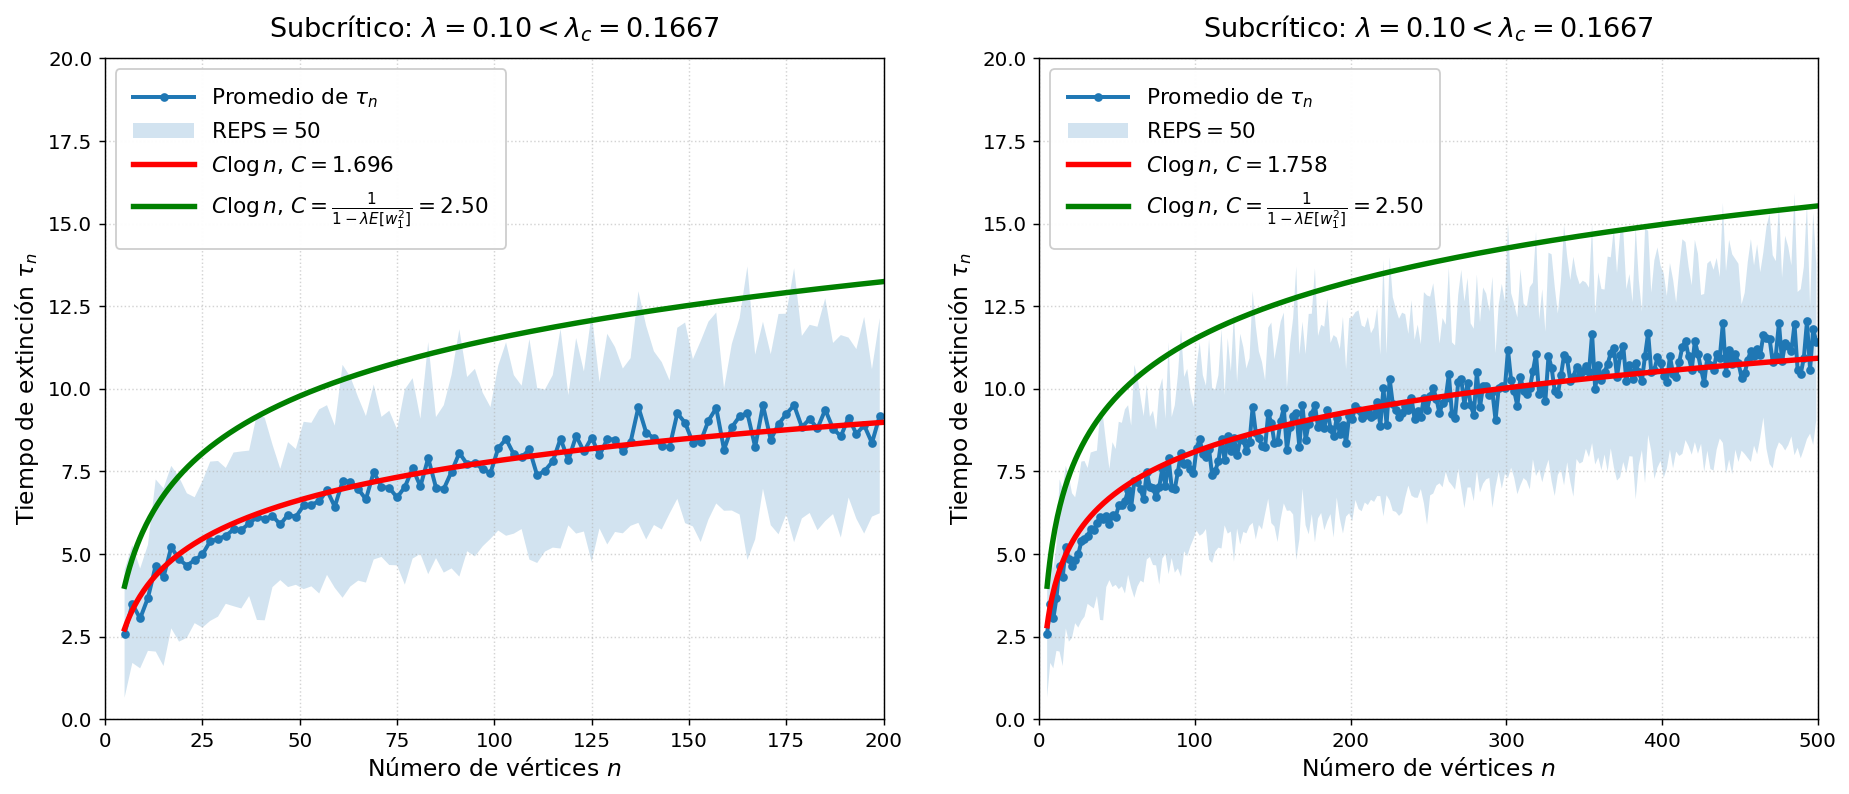

In [ ]:
def panel_subcritico(ax, resultados, n_max, y_max=None):
    n = resultados["n"]
    media = resultados["media"]
    inferior, superior = banda_media_sd(resultados)

    c_log, _, _ = ajuste_logaritmico(resultados)

    n_curva = np.linspace(max(2, n.min()), n_max, 600)

    C0 = 1.0 / (1.0 - LAMBDA_SUB * EW2)

    ax.plot(
        n,
        media,
        marker="o",
        markersize=3.8,
        label=r"Promedio de $\tau_n$",
    )

    ax.fill_between(
        n,
        inferior,
        superior,
        alpha=0.20,
        label=rf"REPS$={resultados['R']}$",
    )


    ax.plot(
        n_curva,
        c_log * np.log(n_curva),
        color="red",
        linewidth=3.0,
        label=rf"$C\log n$, $C={c_log:.3f}$",
    )


    ax.plot(
        n_curva,
        C0 * np.log(n_curva),
        color="green",
        linewidth=3.0,
        linestyle="-",
        label=(
            rf"$C\log n$, "
            rf"$C=\frac{{1}}{{1-\lambda E[w_1^2]}}"
            rf"={C0:.2f}$"
        ),
    )

    estilo_eje_extincion(
        ax,
        rf"Subcrítico: "
        rf"$\lambda={LAMBDA_SUB:.2f}<\lambda_c={LAMBDA_C:.4f}$",
        n_max=n_max,
    )

    if y_max is not None:
        ax.set_ylim(0, y_max)

    leyenda_grande(ax, loc="upper left")



fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6.6),
    gridspec_kw={"wspace": 0.20}
)

panel_subcritico(
    axes[0],
    sub_200,
    200,
    y_max=20
)

panel_subcritico(
    axes[1],
    sub_500,
    500,
    y_max=20
)

plt.show()

# 9. Régimen crítico:

En el régimen crítico

$$
\lambda=\lambda_c=\frac16,
$$

se ajusta $n^{\alpha}$.

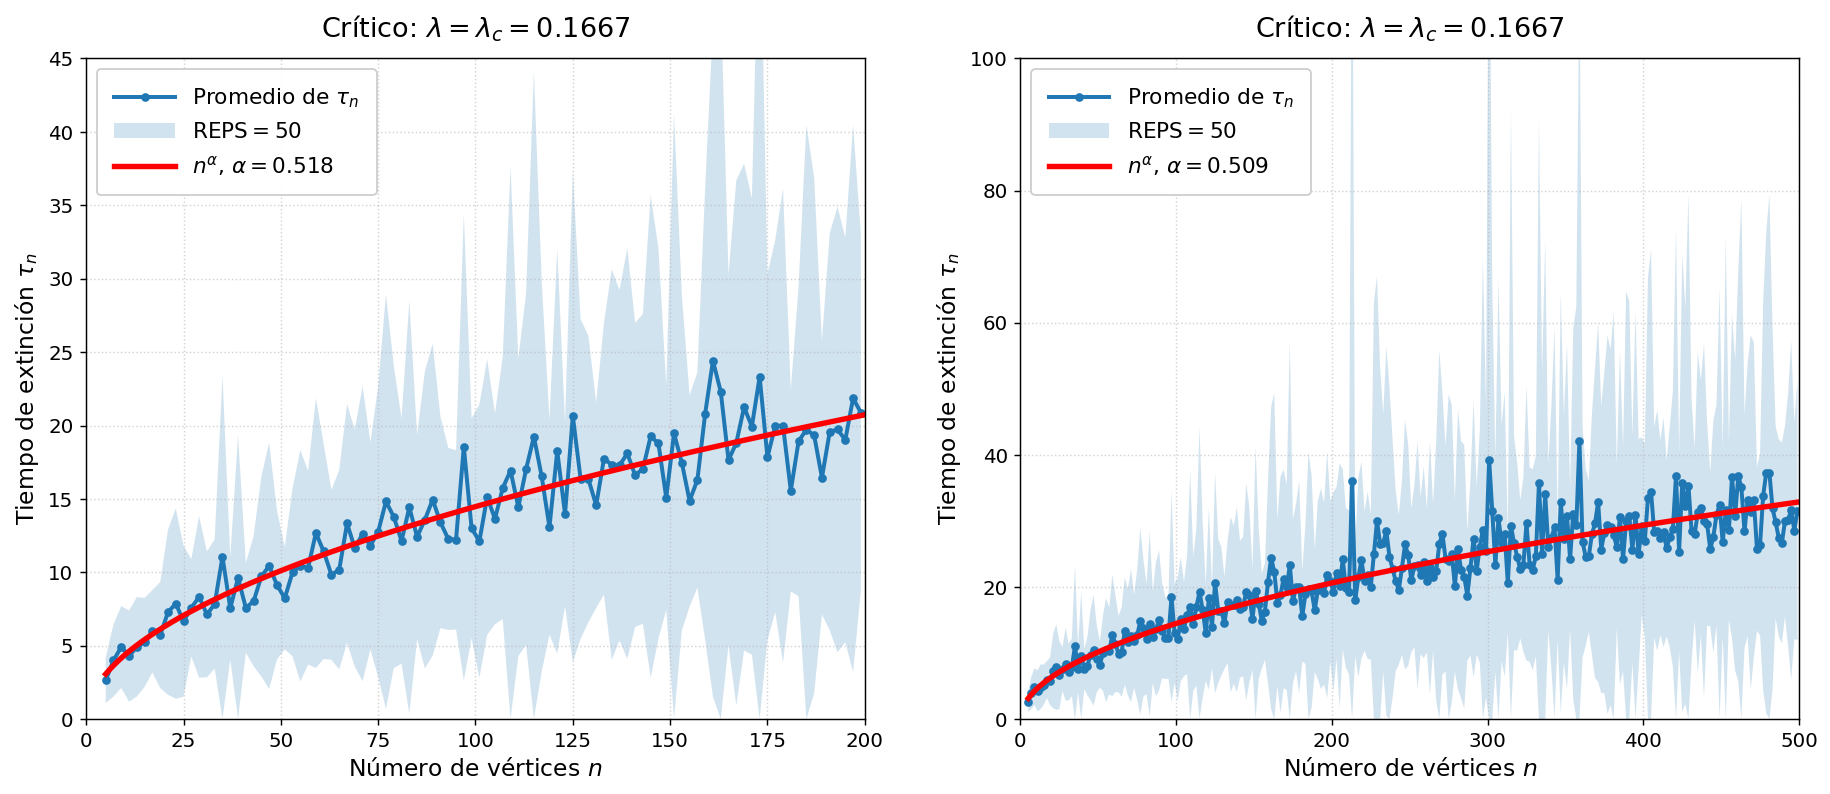

In [ ]:
def panel_critico(ax, resultados, n_max, y_max=None, factor_banda=0.5):
    n = resultados["n"]
    media = resultados["media"]

    sd = resultados["sd"]

    inferior = np.maximum(0, media - factor_banda * sd)
    superior = media + factor_banda * sd

    A, alpha, _, _ = ajuste_polinomial(resultados)
    n_curva = np.linspace(max(2, n.min()), n_max, 600)

    ax.plot(
        n, media,
        marker="o",
        markersize=3.8,
        label=r"Promedio de $\tau_n$",
    )

    ax.fill_between(
        n,
        inferior,
        superior,
        alpha=0.20,
        label=rf"REPS$={resultados['R']}$",
    )

    ax.plot(
        n_curva,
        A * n_curva**alpha,
        color="red",
        linewidth=3.0,
        label=rf"$n^{{\alpha}}$, $\alpha={alpha:.3f}$",
    )

    estilo_eje_extincion(
        ax,
        rf"Crítico: $\lambda=\lambda_c={LAMBDA_C:.4f}$",
        n_max=n_max,
    )

    if y_max is not None:
        ax.set_ylim(0, y_max)

    leyenda_grande(ax, loc="upper left")

fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6.6),
    gridspec_kw={"wspace": 0.20}
)

panel_critico(
    axes[0],
    cri_200,
    200,
    y_max=45,
    factor_banda=1.0
)

panel_critico(
    axes[1],
    cri_500,
    500,
    y_max=100,
    factor_banda=1.0
)

plt.show()

# 10. Régimen supercrítico: crecimiento exponencial

Para

$$
\lambda=0.25>\lambda_c,
$$

se ajusta la curva $e^{cn}$.

Se presentan ahora los dos paneles $n\le200$ y $n\le500$. El número de repeticiones se fija en $R=20$, menor que en los otros dos regímenes, porque el costo de una trayectoria supercrítica aumenta rápidamente con $n$. La curva roja corresponde a una curva exponencial de referencia de la forma $e^{cn}$, coherente con el orden exponencial del régimen supercrítico. En los paneles se utilizan los valores de $c$ indicados en las respectivas leyendas.


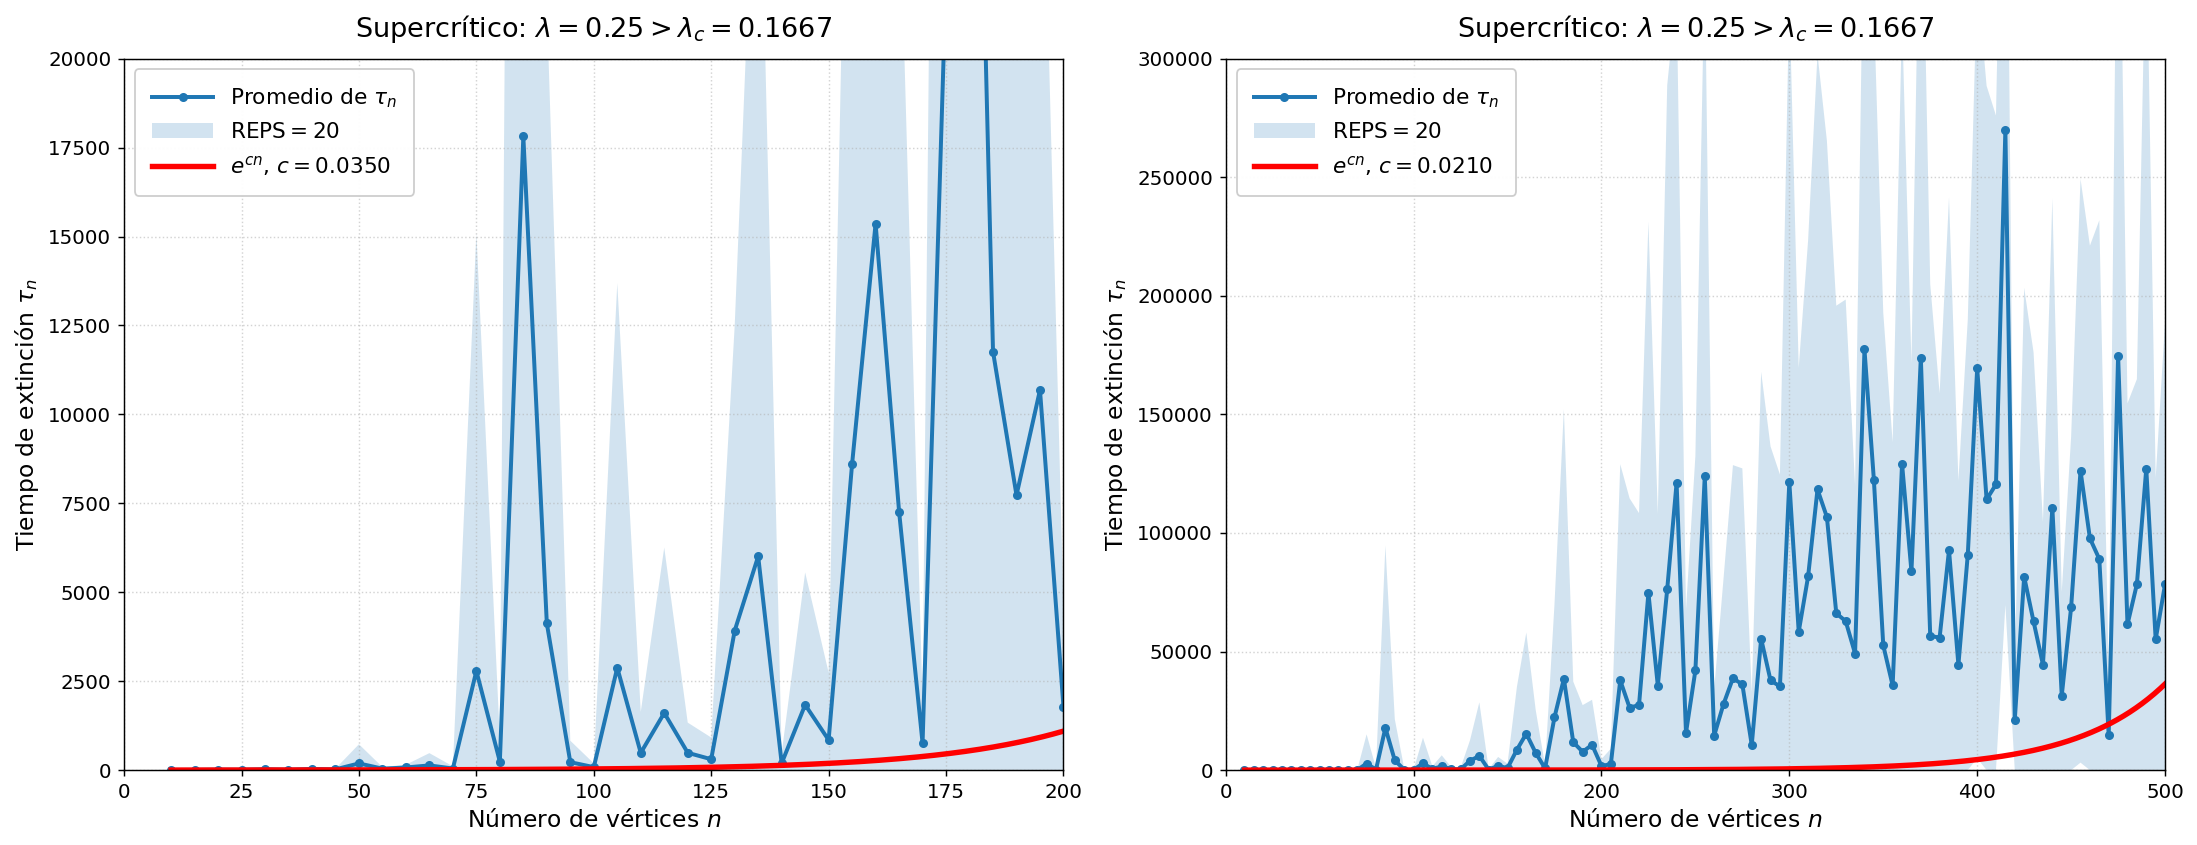

In [ ]:
def panel_supercritico(ax, resultados, n_max, c_ref, y_max=None):
    n = resultados["n"]
    media = resultados["media"]
    inferior, superior = banda_media_sd(resultados)

    n_curva = np.linspace(max(2, n.min()), n_max, 600)

    ax.plot(
        n, media,
        marker="o",
        markersize=4.0,
        label=r"Promedio de $\tau_n$",
    )

    ax.fill_between(
        n, inferior, superior,
        alpha=0.20,
        label=rf"REPS$={resultados['R']}$",
    )

    ax.plot(
        n_curva,
        np.exp(c_ref * n_curva),
        color="red",
        linewidth=3.0,
        label=rf"$e^{{cn}}$, $c={c_ref:.4f}$",
    )

    estilo_eje_extincion(
        ax,
        rf"Supercrítico: $\lambda={LAMBDA_SUP:.2f}>\lambda_c={LAMBDA_C:.4f}$",
        n_max=n_max,
    )

    if y_max is not None:
        ax.set_ylim(0, y_max)

    leyenda_grande(ax, loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(17, 6.6))

panel_supercritico(
    axes[0],
    sup_200,
    200,
    c_ref=0.035,
    y_max=20000
)

panel_supercritico(
    axes[1],
    sup_500,
    500,
    c_ref=0.021,
    y_max=300000
)

fig.tight_layout()
plt.show()

# 11. Comparación régimen crítico respecto a las curvas logarítmicas y exponenciales:

Esta figura reproduce la comparación conceptual entre el régimen crítico y el orden subcrítico y supercrítico, pero utiliza ahora la **curva logarítmica estimada para el régimen subcrítico y una curva exponencial de referencia para el régimen supercrítico**, en lugar de escoger una constante arbitraria.

La diferencia en la rapidez de crecimiento se hace visible a medida que aumenta $n$.

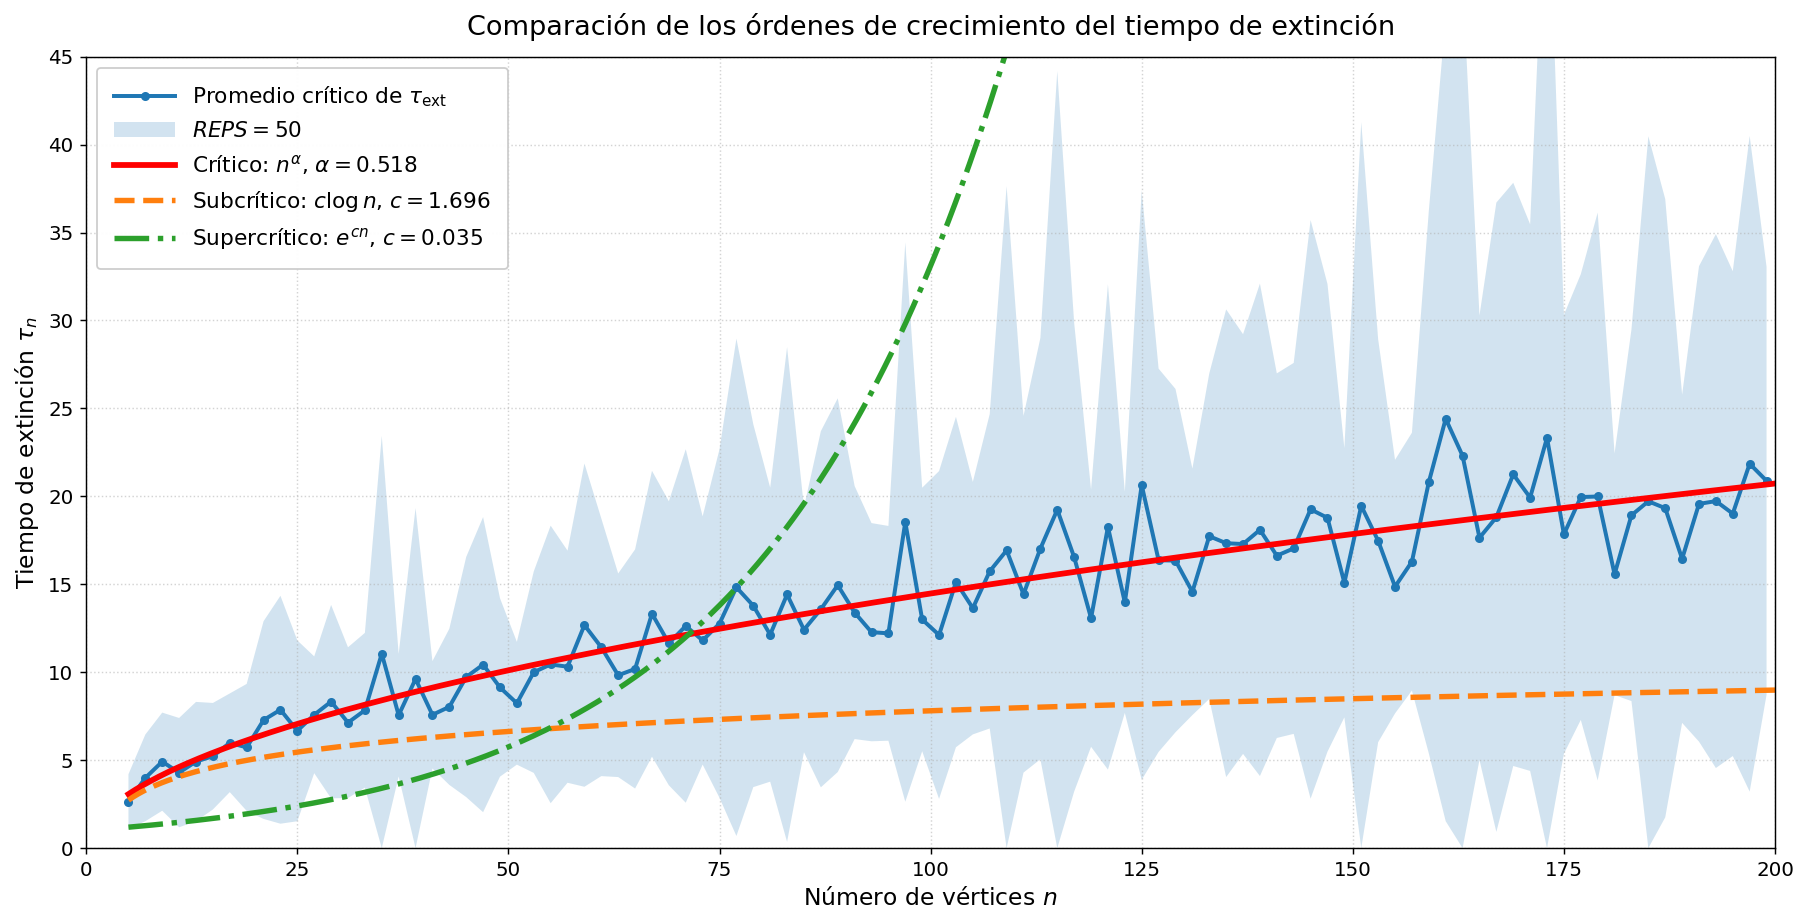

In [ ]:
# n = 200

A_cri_200, alpha_cri_200, _, _ = ajuste_polinomial(cri_200)

c_sub_200, _, _ = ajuste_logaritmico(sub_200)

c_sup_200 = 0.035

y_max = 45

n_curva = np.linspace(5, 200, 700)

inferior, superior = banda_media_sd(cri_200)

fig, ax = plt.subplots(figsize=(14, 7.2))

ax.plot(
    cri_200["n"],
    cri_200["media"],
    marker="o",
    markersize=4.0,
    label=r"Promedio crítico de $\tau_{\mathrm{ext}}$",
)

ax.fill_between(
    cri_200["n"],
    inferior,
    superior,
    alpha=0.20,
    label=rf"$REPS={cri_200['R']}$",
)

ax.plot(
    n_curva,
    A_cri_200 * n_curva**alpha_cri_200,
    color="red",
    linewidth=3.2,
    label=(
        rf"Crítico: $n^{{\alpha}}$, "
        rf"$\alpha={alpha_cri_200:.3f}$"
    ),
)

ax.plot(
    n_curva,
    c_sub_200 * np.log(n_curva),
    linewidth=3.0,
    linestyle="--",
    label=(
        rf"Subcrítico: $c\log n$, "
        rf"$c={c_sub_200:.3f}$"
    ),
)

ax.plot(
    n_curva,
    np.exp(c_sup_200 * n_curva),
    linewidth=3.0,
    linestyle="-.",
    label=(
        rf"Supercrítico: $e^{{cn}}$, "
        rf"$c={c_sup_200:.3f}$"
    ),
)

estilo_eje_extincion(
    ax,
    "Comparación de los órdenes de crecimiento del tiempo de extinción",
    n_max=200,
)

ax.set_ylim(0, y_max)

leyenda_grande(ax, loc="upper left")

fig.tight_layout()
plt.show()

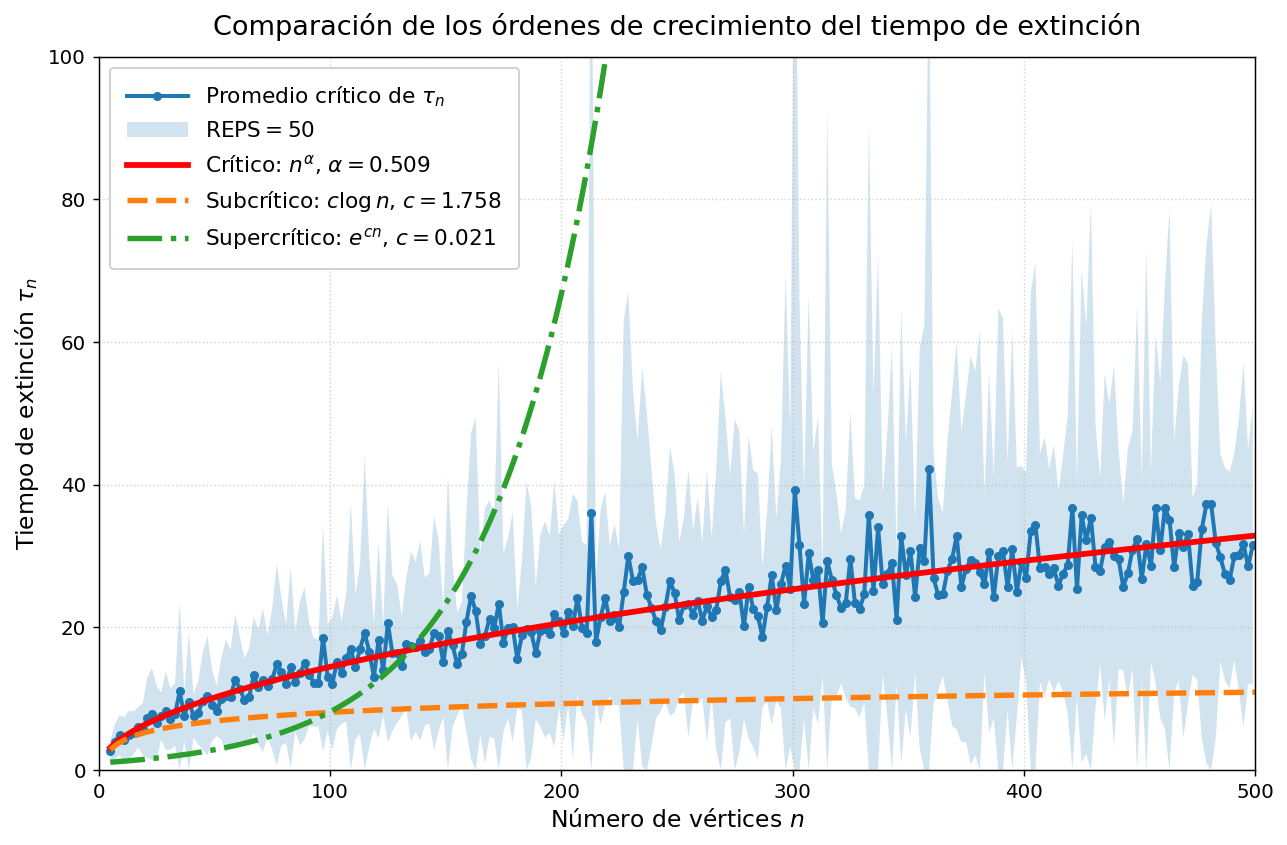

In [ ]:
# n = 500

A_cri_500, alpha_cri_500, _, _ = ajuste_polinomial(cri_500)
c_sub_500, _, _ = ajuste_logaritmico(sub_500)
c_sup_500 = 0.021
y_max = 100
n_curva = np.linspace(5, 500, 1000)
inferior, superior = banda_media_sd(cri_500)

fig, ax = plt.subplots(figsize=(10, 6.6))

ax.plot(
    cri_500["n"],
    cri_500["media"],
    marker="o",
    markersize=4.0,
    label=r"Promedio crítico de $\tau_n$",
)

ax.fill_between(
    cri_500["n"],
    inferior,
    superior,
    alpha=0.20,
    label=rf"REPS$={cri_500['R']}$",
)

ax.plot(
    n_curva,
    A_cri_500 * n_curva**alpha_cri_500,
    color="red",
    linewidth=3.2,
    label=(
        rf"Crítico: $n^{{\alpha}}$, "
        rf"$\alpha={alpha_cri_500:.3f}$"
    ),
)

ax.plot(
    n_curva,
    c_sub_500 * np.log(n_curva),
    linewidth=3.0,
    linestyle="--",
    label=(
        rf"Subcrítico: $c\log n$, "
        rf"$c={c_sub_500:.3f}$"
    ),
)

ax.plot(
    n_curva,
    np.exp(c_sup_500 * n_curva),
    linewidth=3.0,
    linestyle="-.",
    label=(
        rf"Supercrítico: $e^{{cn}}$, "
        rf"$c={c_sup_500:.3f}$"
    ),
)

estilo_eje_extincion(
    ax,
    "Comparación de los órdenes de crecimiento del tiempo de extinción",
    n_max=500,
)

ax.set_ylim(0, y_max)

leyenda_grande(ax, loc="upper left")

fig.tight_layout()
plt.show()

## 12. Reproducibilidad y costo computacional

Las semillas se fijan explícitamente para las realizaciones de los pesos y para la evolución del proceso. Las dependencias principales son `numpy`, `matplotlib` y `numba`. El régimen supercrítico puede requerir un tiempo de cómputo considerable y puede presentar trayectorias censuradas por `MAX_EVENTOS_EXT`; antes de interpretar los promedios, debe revisarse el vector `censurados`.
